<a href="https://colab.research.google.com/github/Rubaiat-Islam-Siam/Machine-Learning-Course/blob/main/Binning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv("train_and_test2.csv", usecols=["Age","Fare","Survived"])

In [ ]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [ ]:
df.dropna(inplace = True)

In [ ]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [ ]:
df.shape

(331, 3)

In [ ]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [ ]:
X_train , X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=42)

In [ ]:
X_train.head()

,Age,Fare
281,0.75,13.7750
96,76.00,78.8500
341,32.00,7.5792
18,27.00,7.9250
26,22.00,61.9792


In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.5671641791044776

In [ ]:
scores = cross_val_score(
    DecisionTreeClassifier(random_state=42),
    X,
    y,
    cv=10,
    scoring='accuracy'
)
np.mean(scores)

np.float64(0.5558823529411765)

In [ ]:
kbin_ages = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15, encode='ordinal', strategy='quantile')

In [ ]:
trf = ColumnTransformer([
    ('first',kbin_ages,[0]),
    ('second',kbin_fare,[1])
],remainder='passthrough')

In [ ]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [ ]:
trf.named_transformers_['first'].n_bins_

array([15])

In [ ]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.33      , 13.53333333, 18.        , 20.        , 22.        ,
              24.        , 25.2       , 27.73333333, 30.        , 32.        ,
              36.        , 39.        , 43.8       , 47.93333333, 55.        ,
              76.        ])                                                   ],
      dtype=object)

In [ ]:
output = pd.DataFrame({
    'age': X_train['Age'],
    'age_trf': X_train_trf[:, 0],
    'fare': X_train['Fare'],
    'fare_trf': X_train_trf[:, 1]
})

In [ ]:
output['age_labels'] = pd.cut(
    x=X_train['Age'],
    bins=trf.named_transformers_['first'].bin_edges_[0].tolist()
)
output['fare_labels'] = pd.cut(
    x=X_train['Fare'],
    bins=trf.named_transformers_['second'].bin_edges_[0].tolist()
)

In [ ]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
285,36.0,10.0,7.2500,0.0,"(32.0, 36.0]","(0.0, 7.426]"
212,17.0,1.0,73.5000,12.0,"(13.533, 18.0]","(58.41, 78.679]"
279,22.0,4.0,10.5000,4.0,"(20.0, 22.0]","(8.662, 12.253]"
196,6.0,0.0,134.5000,13.0,"(0.33, 13.533]","(78.679, 141.325]"
110,41.0,11.0,15.0458,7.0,"(39.0, 43.8]","(14.891, 21.0]"


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [ ]:
accuracy_score(y_test,y_pred2)


0.5970149253731343

In [ ]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

np.float64(0.5772727272727274)

In [ ]:
def discretize(bins, strategy):

    # -----------------------------
    # 1. Create discretizers
    # -----------------------------

    kbin_age = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )

    kbin_fare = KBinsDiscretizer(
        n_bins=bins,
        encode='ordinal',
        strategy=strategy
    )


    # -----------------------------
    # 2. Apply transformers
    # -----------------------------

    trf = ColumnTransformer([
        ('first', kbin_age, [0]),   # Age
        ('second', kbin_fare, [1])  # Fare
    ])


    # -----------------------------
    # 3. Transform X
    # -----------------------------

    X_trf = trf.fit_transform(X)


    # -----------------------------
    # 4. Decision Tree Accuracy
    # -----------------------------

    accuracy = np.mean(
        cross_val_score(
            DecisionTreeClassifier(random_state=42),
            X_trf,
            y,
            cv=10,
            scoring='accuracy'
        )
    )

    print("Strategy:", strategy)
    print("Number of bins:", bins)
    print("Mean Accuracy:", accuracy)


    # -----------------------------
    # 5. Create plots
    # -----------------------------

    plt.figure(figsize=(14, 4))


    # Original Age
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before Discretization")
    plt.xlabel("Age")
    plt.ylabel("Frequency")


    # Transformed Age
    plt.subplot(122)
    plt.hist(X_trf[:, 0], color='red')
    plt.title("After Discretization")
    plt.xlabel("Age Bin")
    plt.ylabel("Frequency")


    plt.show()


    # -----------------------------
    # 6. Return transformed data
    # -----------------------------



Strategy: kmeans
Number of bins: 10
Mean Accuracy: 0.6014260249554367


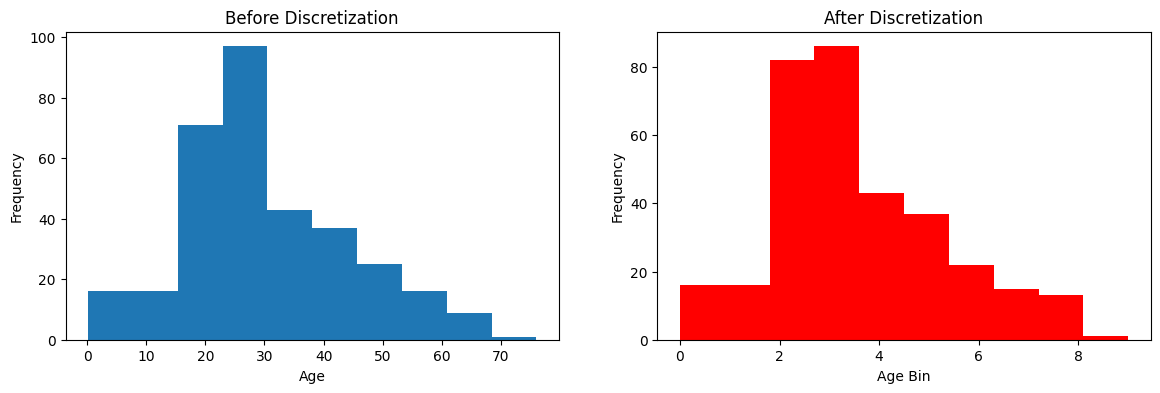

In [ ]:
discretize(10, 'kmeans')

Strategy: uniform
Number of bins: 10
Mean Accuracy: 0.5923351158645277


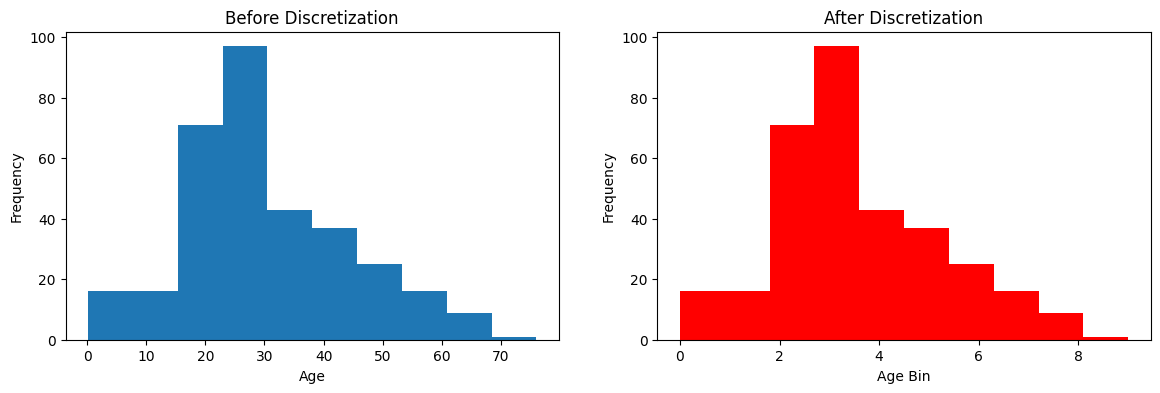

In [ ]:
discretize(10, 'uniform')

Strategy: quantile
Number of bins: 10
Mean Accuracy: 0.5590909090909092


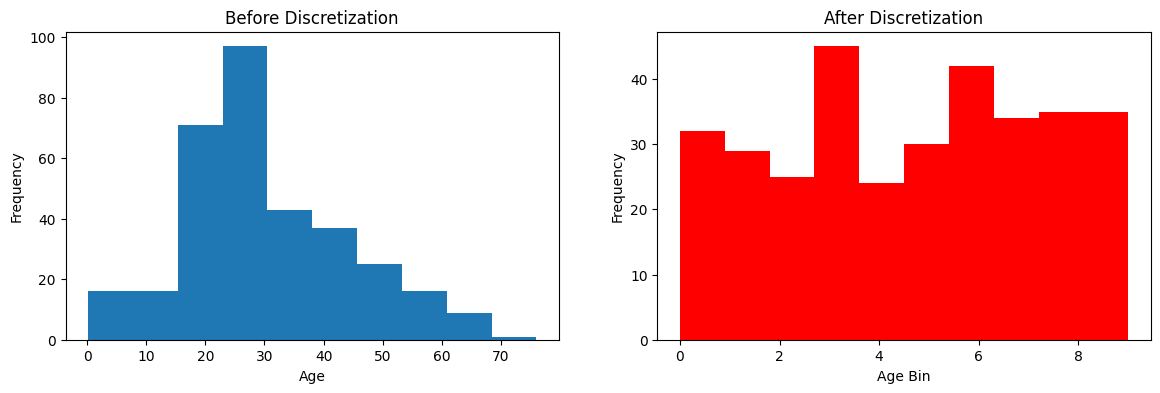

In [ ]:
discretize(10, 'quantile')